In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("final_df.csv")

In [3]:
df.head(10)

,Unnamed: 0,Date,Open,High,Low,Close,Volume,Stock
0,0,2025-03-27 03:45:00,1278.150024,1285.000000,1271.300049,1278.199951,15028056,RELIANCE.NS
1,1,2025-03-28 03:45:00,1280.000000,1295.750000,1269.000000,1275.099976,18147129,RELIANCE.NS
2,2,2025-04-01 03:45:00,1264.599976,1277.900024,1249.300049,1252.599976,12099648,RELIANCE.NS
3,3,2025-04-02 03:45:00,1247.550049,1255.550049,1243.900024,1251.150024,10142590,RELIANCE.NS
4,4,2025-04-03 03:45:00,1233.050049,1251.800049,1233.050049,1248.699951,7434366,RELIANCE.NS
5,5,2025-04-04 03:45:00,1241.099976,1245.449951,1193.150024,1204.699951,17908652,RELIANCE.NS
6,6,2025-04-07 03:45:00,1132.199951,1171.250000,1114.849976,1165.699951,22156106,RELIANCE.NS
7,7,2025-04-08 03:45:00,1172.000000,1196.599976,1163.300049,1182.199951,19555040,RELIANCE.NS
8,8,2025-04-09 03:45:00,1169.500000,1189.800049,1168.000000,1185.349976,10223104,RELIANCE.NS
9,9,2025-04-11 03:45:00,1195.150024,1222.650024,1195.150024,1218.949951,11224242,RELIANCE.NS


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2490 entries, 0 to 2489
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2490 non-null   int64  
 1   Date        2490 non-null   object 
 2   Open        2490 non-null   float64
 3   High        2490 non-null   float64
 4   Low         2490 non-null   float64
 5   Close       2480 non-null   float64
 6   Volume      2490 non-null   int64  
 7   Stock       2490 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 155.8+ KB


In [5]:
df.isna().sum()

Unnamed: 0     0
Date           0
Open           0
High           0
Low            0
Close         10
Volume         0
Stock          0
dtype: int64

In [6]:
df = df.dropna()

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop(columns=['Unnamed: 0'])

In [9]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Stock", "Date"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2480 entries, 2241 to 497
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2480 non-null   datetime64[ns]
 1   Open    2480 non-null   float64       
 2   High    2480 non-null   float64       
 3   Low     2480 non-null   float64       
 4   Close   2480 non-null   float64       
 5   Volume  2480 non-null   int64         
 6   Stock   2480 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 155.0+ KB


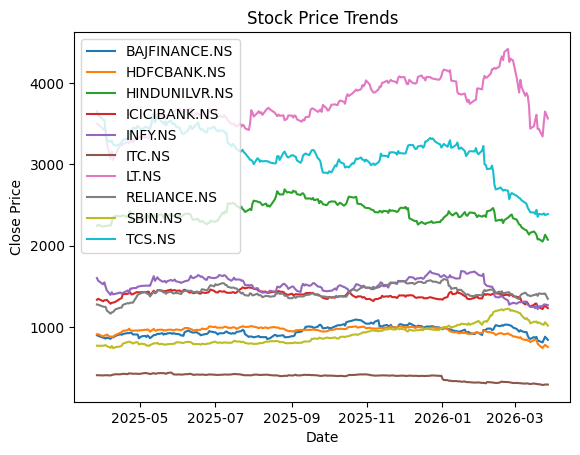

In [11]:
import matplotlib.pyplot as plt

plt.figure()

for stock in df["Stock"].unique():
    subset = df[df["Stock"] == stock]
    plt.plot(subset["Date"], subset["Close"], label=stock)

plt.legend()
plt.title("Stock Price Trends")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

In [12]:
df["Return"] = (df['Close'] - df['Open']) / df['Open']

In [13]:
df["Volume_Change"] = df.groupby("Stock")["Volume"].pct_change()

In [14]:
df["Daily_Range"] = df["High"] - df["Low"]

In [15]:
df["Intraday_Volatility"] = (
    df["Daily_Range"] / df["Open"]
)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2480 entries, 2241 to 497
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 2480 non-null   datetime64[ns]
 1   Open                 2480 non-null   float64       
 2   High                 2480 non-null   float64       
 3   Low                  2480 non-null   float64       
 4   Close                2480 non-null   float64       
 5   Volume               2480 non-null   int64         
 6   Stock                2480 non-null   object        
 7   Return               2480 non-null   float64       
 8   Volume_Change        2470 non-null   float64       
 9   Daily_Range          2480 non-null   float64       
 10  Intraday_Volatility  2480 non-null   float64       
dtypes: datetime64[ns](1), float64(8), int64(1), object(1)
memory usage: 232.5+ KB


In [17]:
df.head(10)

,Date,Open,High,Low,Close,Volume,Stock,Return,Volume_Change,Daily_Range,Intraday_Volatility
2241,2025-03-27 03:45:00,886.099976,905.539978,882.224976,900.385010,20920440,BAJFINANCE.NS,0.016121,NaN,23.315002,0.026312
2242,2025-03-28 03:45:00,899.760010,902.890015,886.099976,894.559998,9770990,BAJFINANCE.NS,-0.005779,-0.532945,16.790039,0.018661
2243,2025-04-01 03:45:00,878.330017,892.500000,867.099976,869.820007,11834240,BAJFINANCE.NS,-0.009689,0.211161,25.400024,0.028919
2244,2025-04-02 03:45:00,873.000000,875.984985,861.200012,866.924988,6464950,BAJFINANCE.NS,-0.006959,-0.453708,14.784973,0.016936
2245,2025-04-03 03:45:00,865.000000,876.500000,846.020020,859.460022,13966330,BAJFINANCE.NS,-0.006405,1.160315,30.479980,0.035237
2246,2025-04-04 03:45:00,865.599976,879.700012,858.380005,871.885010,18496580,BAJFINANCE.NS,0.007261,0.324369,21.320007,0.024630
2247,2025-04-07 03:45:00,834.000000,860.049988,830.715027,856.799988,13981240,BAJFINANCE.NS,0.027338,-0.244118,29.334961,0.035174
2248,2025-04-08 03:45:00,865.000000,887.299988,865.000000,882.224976,14775630,BAJFINANCE.NS,0.019913,0.056818,22.299988,0.025780
2249,2025-04-09 03:45:00,881.500000,884.200012,862.500000,873.580017,10487740,BAJFINANCE.NS,-0.008985,-0.290200,21.700012,0.024617
2250,2025-04-11 03:45:00,882.505005,897.349976,881.070007,892.109985,10097220,BAJFINANCE.NS,0.010884,-0.037236,16.279968,0.018447


In [18]:
pivot_df = df.pivot(index="Date", columns="Stock", values="Close")

In [19]:
corr = pivot_df.corr()
print(corr)

Stock          BAJFINANCE.NS  HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS  \
Stock                                                                    
BAJFINANCE.NS       1.000000     0.382213       0.270021     -0.039655   
HDFCBANK.NS         0.382213     1.000000       0.563548      0.649363   
HINDUNILVR.NS       0.270021     0.563548       1.000000      0.476318   
ICICIBANK.NS       -0.039655     0.649363       0.476318      1.000000   
INFY.NS             0.136039     0.636362       0.141586      0.414409   
ITC.NS              0.001390     0.720849       0.405026      0.486152   
LT.NS               0.688990     0.118380      -0.032390     -0.114250   
RELIANCE.NS         0.478546     0.457538      -0.047086      0.113541   
SBIN.NS             0.395559    -0.442776      -0.331385     -0.432742   
TCS.NS             -0.117802     0.570003       0.112475      0.538669   

Stock           INFY.NS    ITC.NS     LT.NS  RELIANCE.NS   SBIN.NS    TCS.NS  
Stock                           

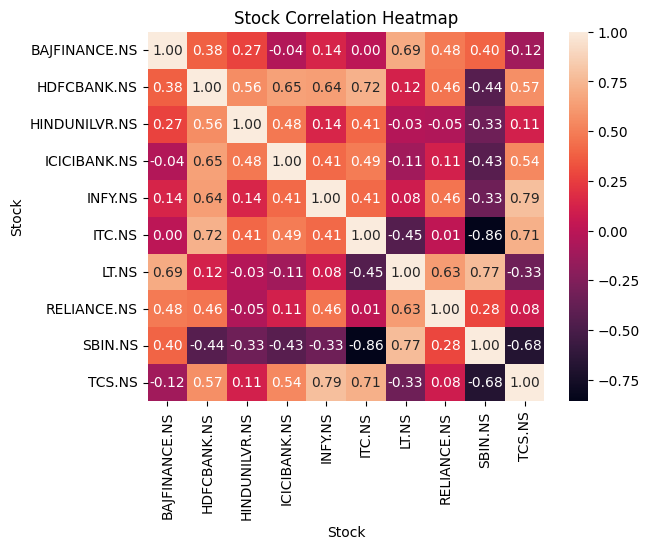

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(corr, annot=True, fmt=".2f")

plt.title("Stock Correlation Heatmap")
plt.show()

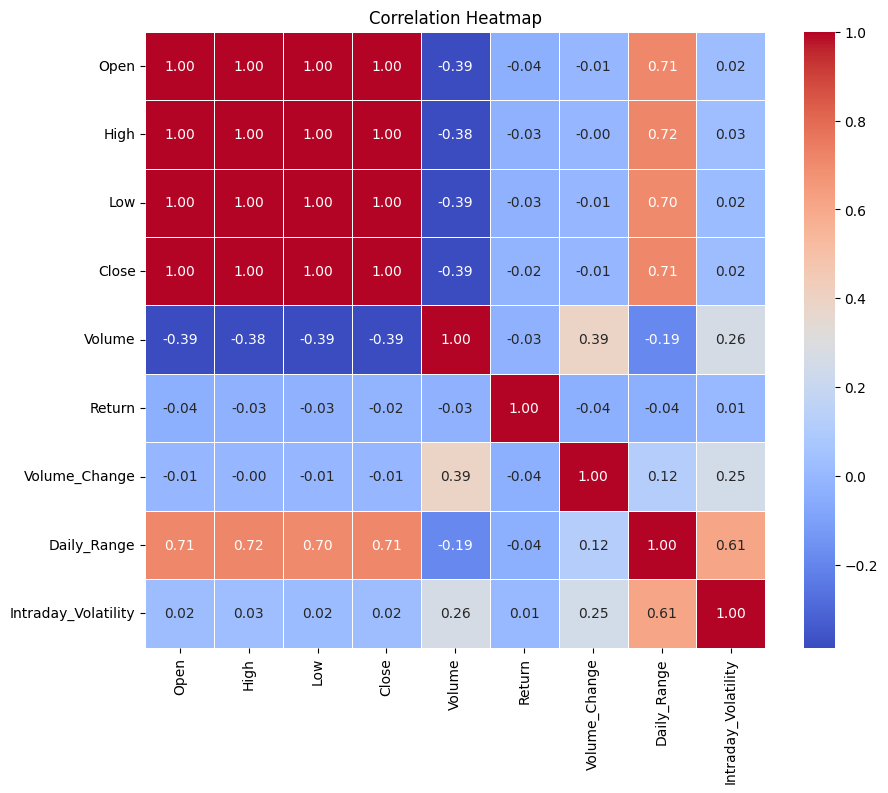

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

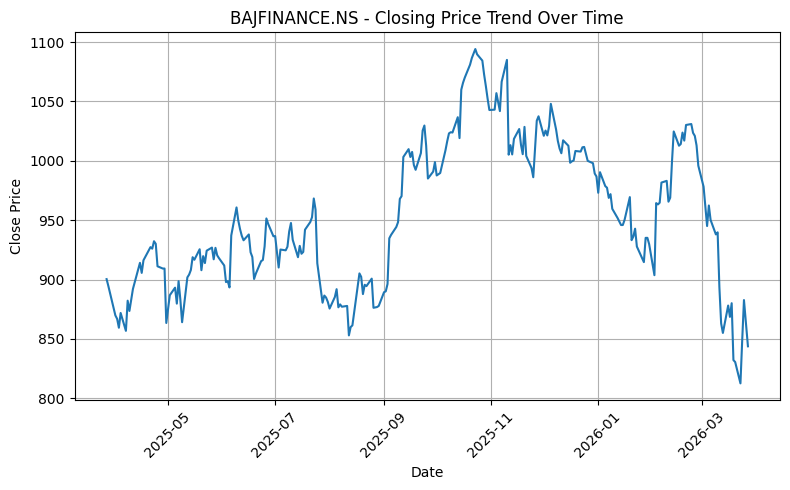

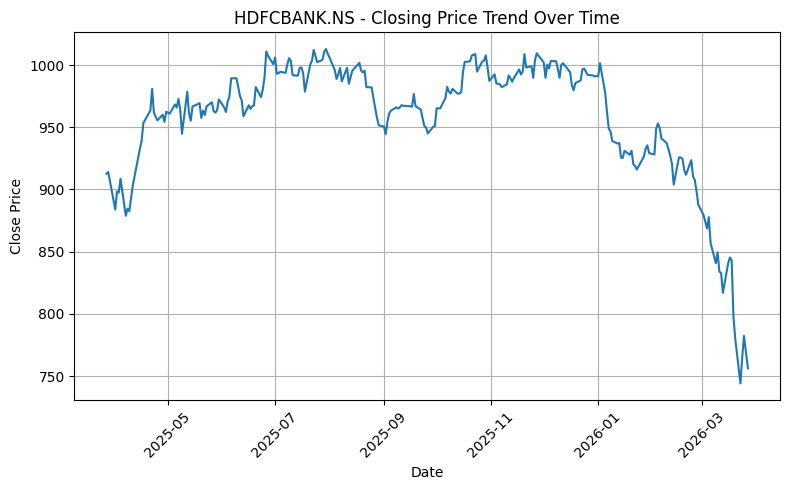

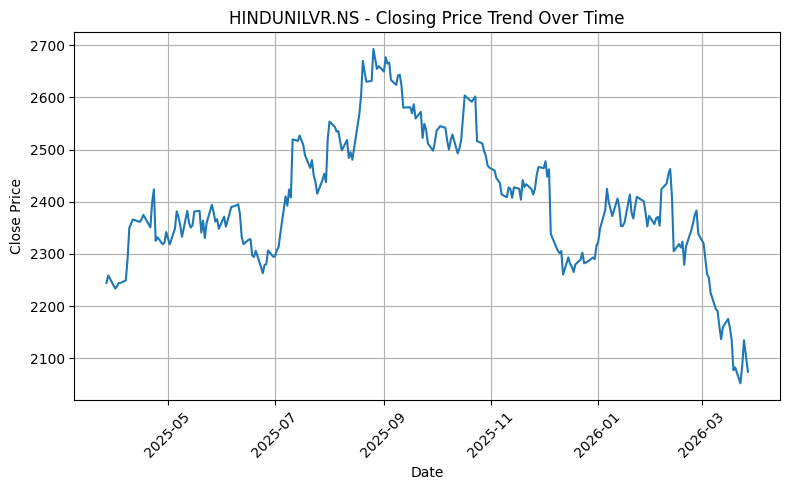

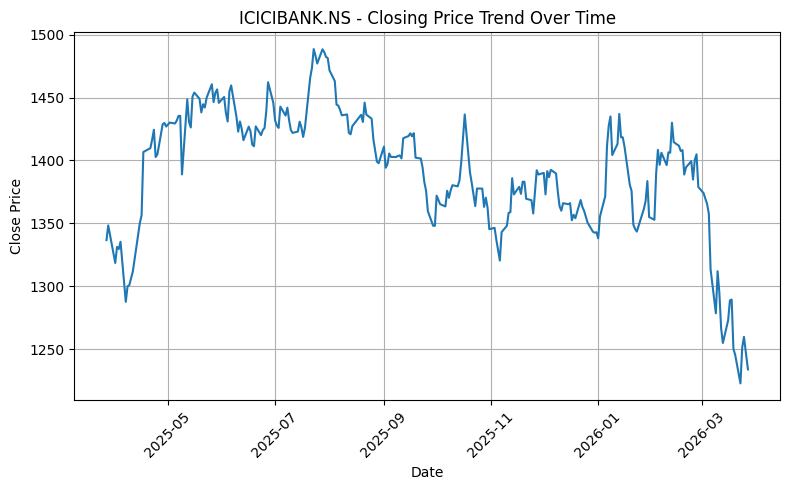

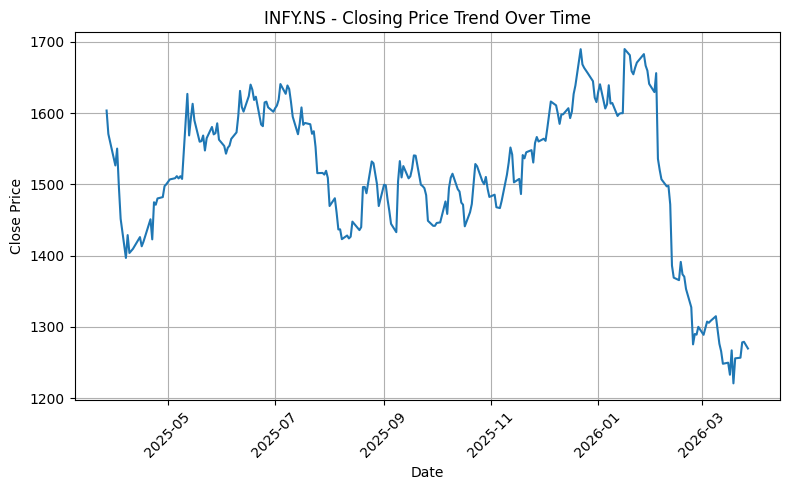

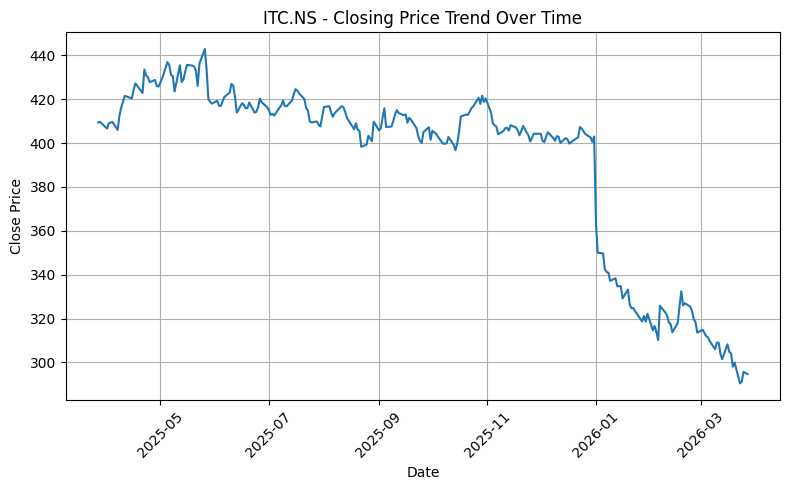

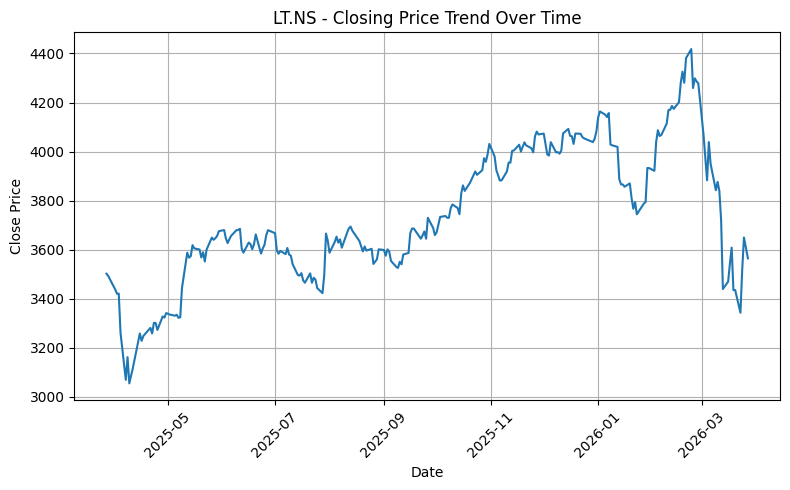

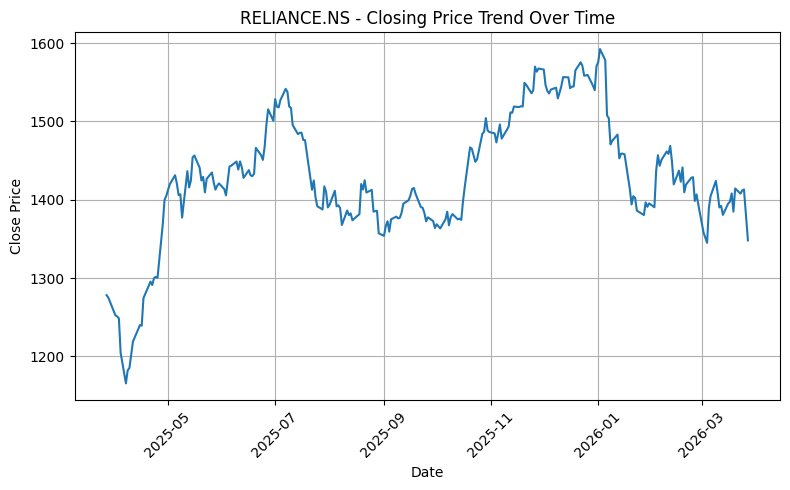

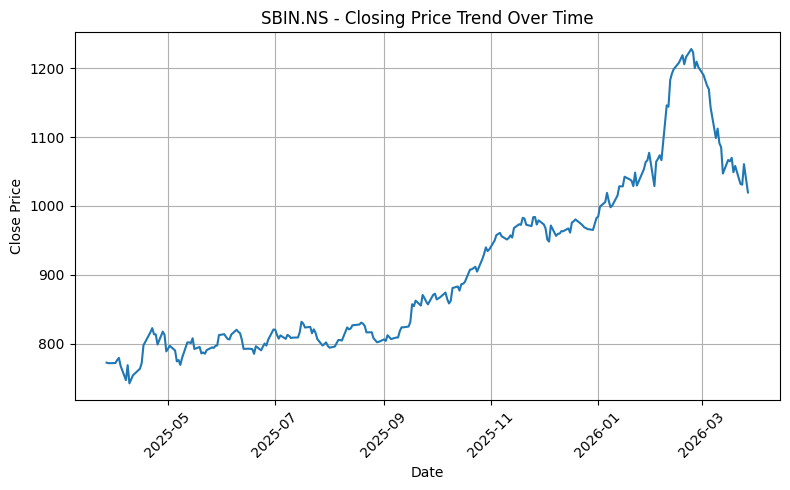

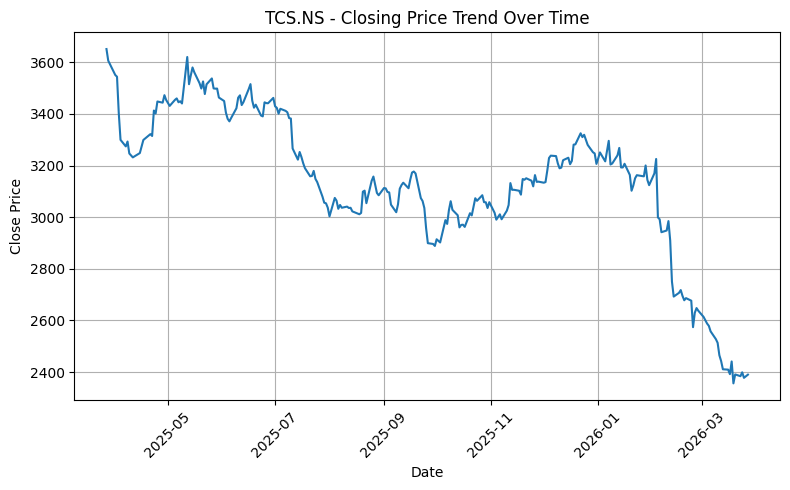

In [22]:
import pandas as pd
import matplotlib.pyplot as plt


final_df = df.sort_values(by=['Stock', 'Date'])

stocks = final_df['Stock'].unique()

for stock in stocks:
    stock_df = final_df[final_df['Stock'] == stock]
    
    plt.figure(figsize=(8, 5))
    plt.plot(stock_df['Date'], stock_df['Close'])
    
    plt.title(f"{stock} - Closing Price Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    
    plt.show()

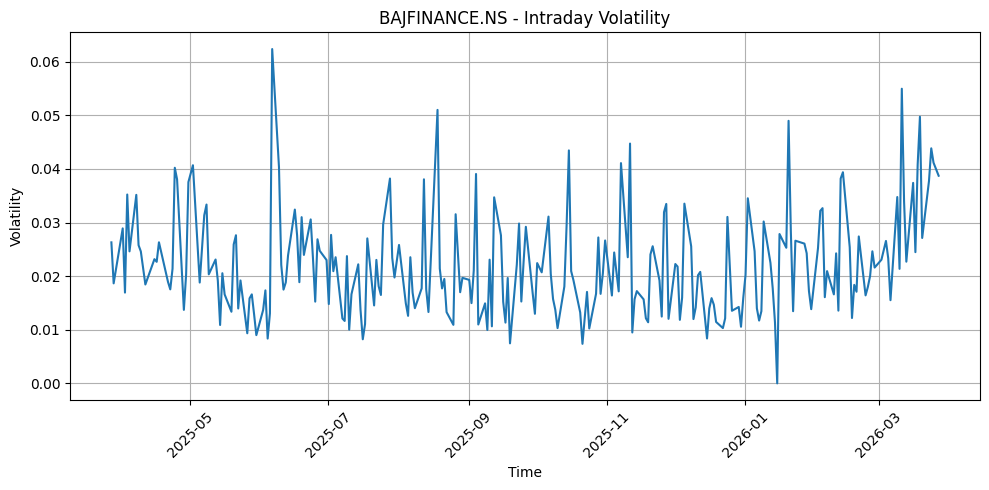

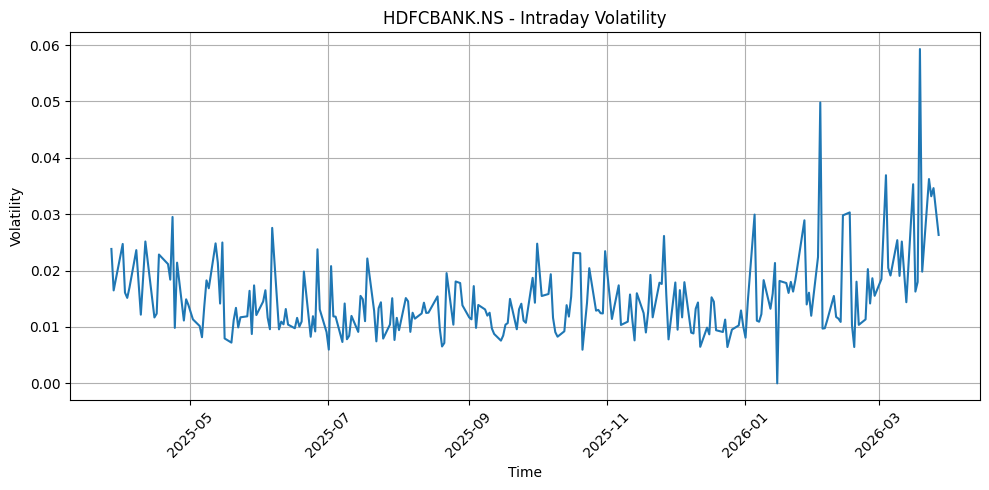

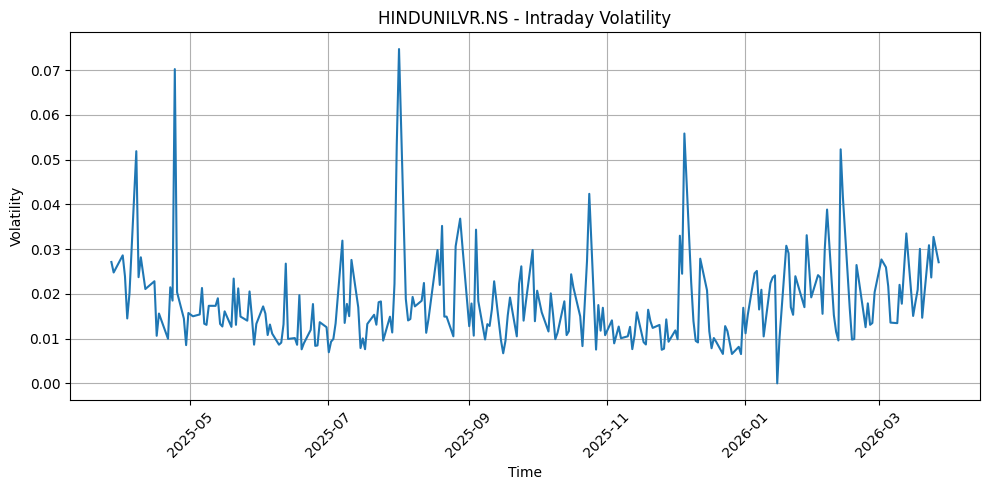

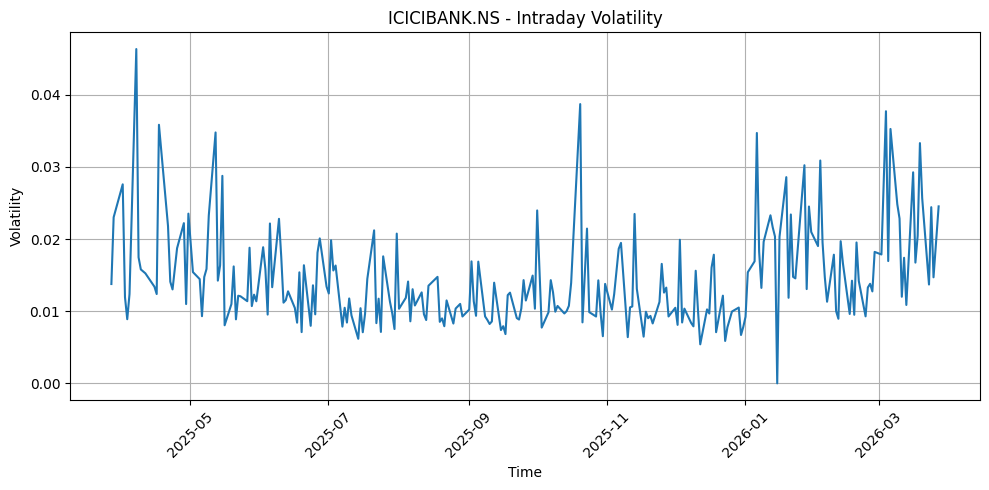

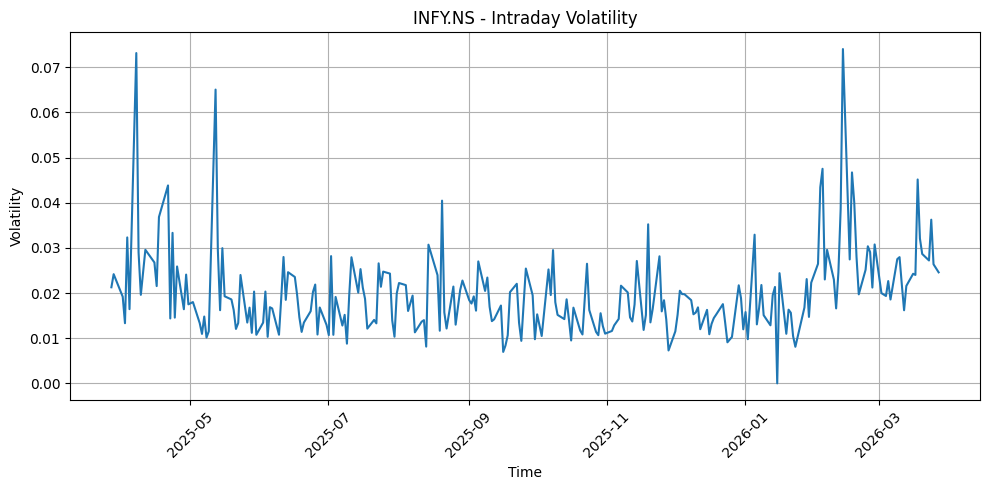

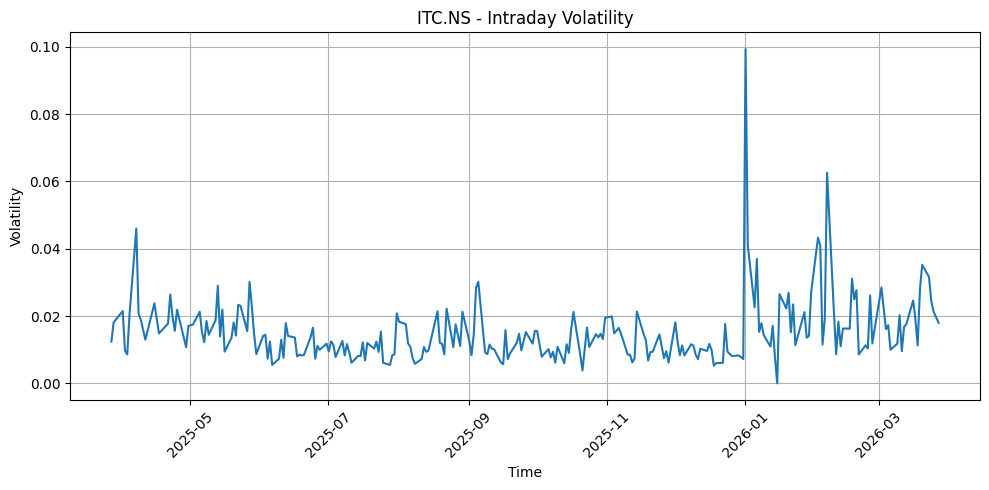

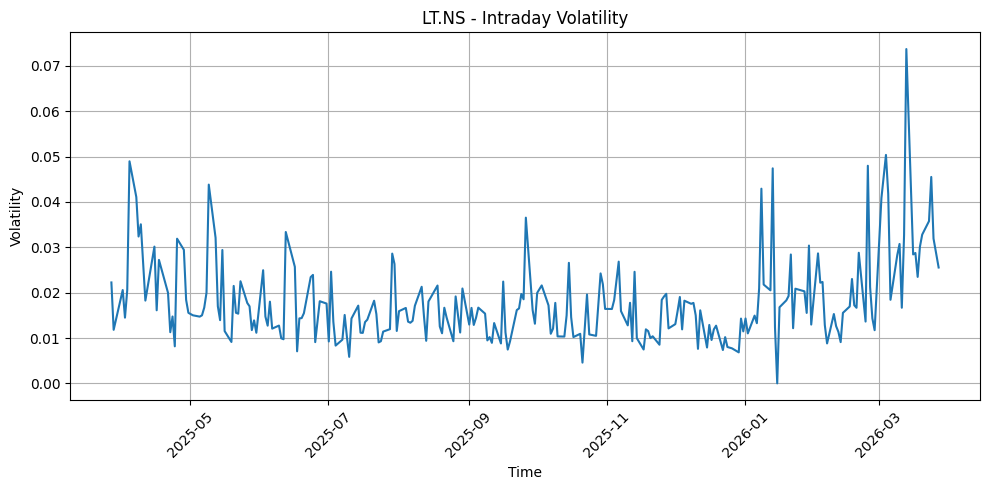

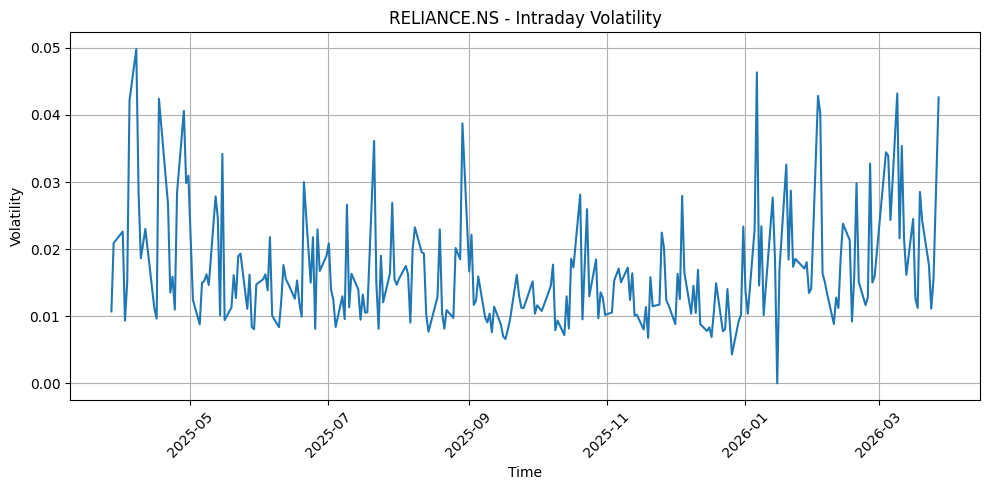

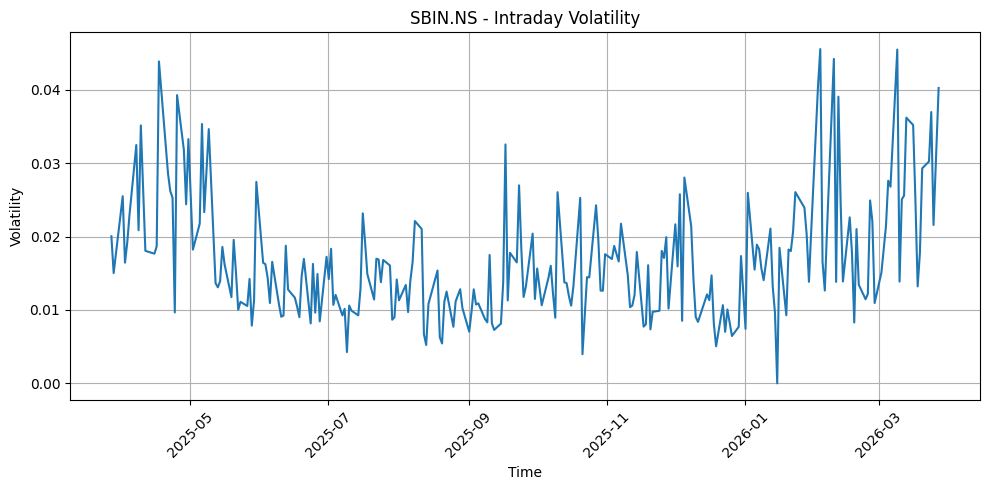

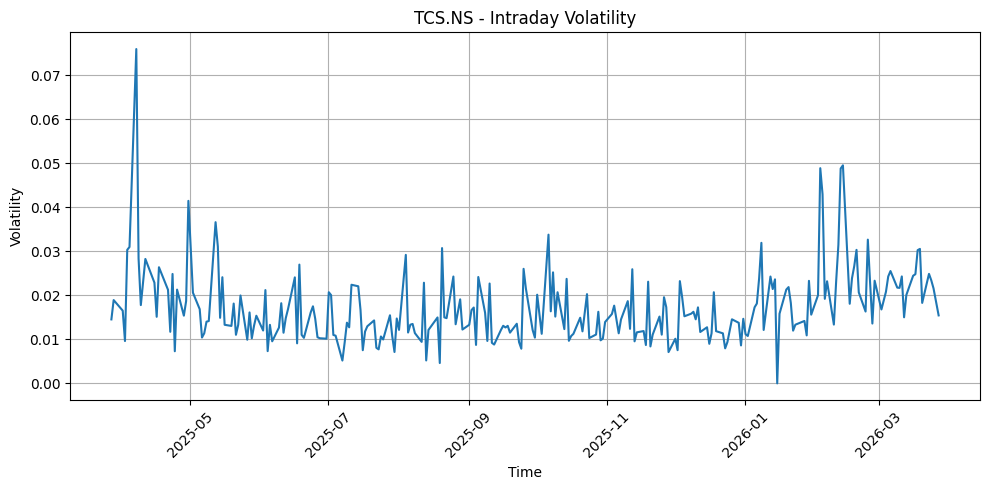

In [23]:
stocks = df['Stock'].unique()

for stock in stocks:
    stock_df = df[df['Stock'] == stock]
    
    plt.figure(figsize=(10, 5))
    plt.plot(stock_df['Date'], stock_df['Intraday_Volatility'])
    
    plt.title(f"{stock} - Intraday Volatility")
    plt.xlabel("Time")
    plt.ylabel("Volatility")
    
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    
    plt.show()

In [24]:
mean_volatility = df.groupby('Stock')['Intraday_Volatility'].mean().sort_values(ascending=False)

print(mean_volatility)

Stock
BAJFINANCE.NS    0.022011
INFY.NS          0.019774
LT.NS            0.017949
HINDUNILVR.NS    0.017940
TCS.NS           0.017129
SBIN.NS          0.016676
RELIANCE.NS      0.016647
ITC.NS           0.015003
HDFCBANK.NS      0.014934
ICICIBANK.NS     0.014388
Name: Intraday_Volatility, dtype: float64


In [25]:
mean_volatility_df = mean_volatility.reset_index()
mean_volatility_df.columns = ['Stock', 'Mean_Volatility']

print(mean_volatility_df)

           Stock  Mean_Volatility
0  BAJFINANCE.NS         0.022011
1        INFY.NS         0.019774
2          LT.NS         0.017949
3  HINDUNILVR.NS         0.017940
4         TCS.NS         0.017129
5        SBIN.NS         0.016676
6    RELIANCE.NS         0.016647
7         ITC.NS         0.015003
8    HDFCBANK.NS         0.014934
9   ICICIBANK.NS         0.014388


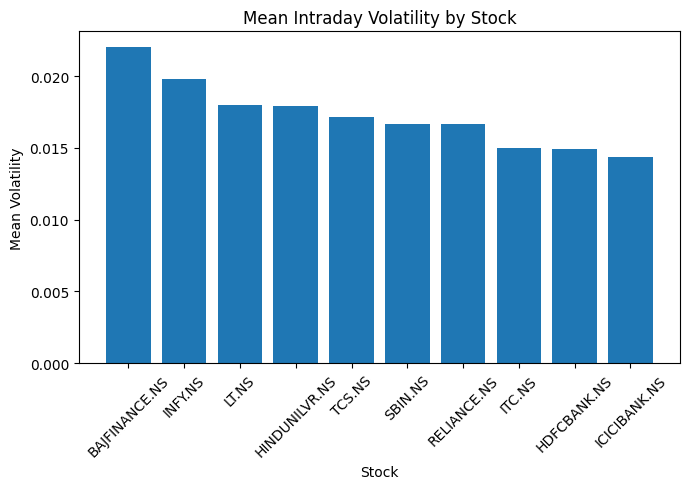

In [26]:
plt.figure(figsize=(7, 5))
plt.bar(mean_volatility_df['Stock'], mean_volatility_df['Mean_Volatility'])

plt.title("Mean Intraday Volatility by Stock")
plt.xlabel("Stock")
plt.ylabel("Mean Volatility")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Stock', 'Return',
       'Volume_Change', 'Daily_Range', 'Intraday_Volatility'],
      dtype='object')

In [28]:
mean_volume = df.groupby("Stock")["Volume"].mean()

In [29]:
mean_volume

Stock
BAJFINANCE.NS    8.516423e+06
HDFCBANK.NS      2.382332e+07
HINDUNILVR.NS    1.700591e+06
ICICIBANK.NS     1.154626e+07
INFY.NS          8.948635e+06
ITC.NS           1.881967e+07
LT.NS            2.067074e+06
RELIANCE.NS      1.184156e+07
SBIN.NS          1.127947e+07
TCS.NS           2.999725e+06
Name: Volume, dtype: float64

In [30]:
mean_volume_df = mean_volume.reset_index()
mean_volume_df.columns = ['Stock','Mean_volume']

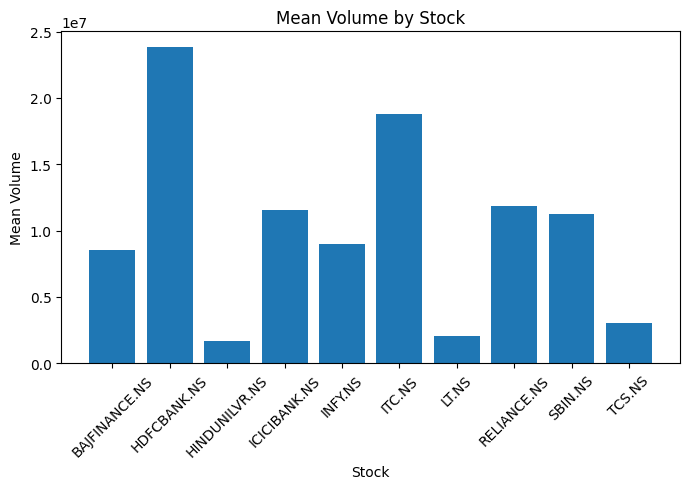

In [31]:
plt.figure(figsize=(7, 5))
plt.bar(mean_volume_df['Stock'], mean_volume_df['Mean_volume'])

plt.title("Mean Volume by Stock")
plt.xlabel("Stock")
plt.ylabel("Mean Volume")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
features = df.groupby("Stock").agg({
    "Return": "mean",
    "Intraday_Volatility": "mean"
})

features.columns = ["Avg_Return", "Avg_Intraday_Vol"]
features.reset_index(inplace=True)

print(features)

           Stock  Avg_Return  Avg_Intraday_Vol
0  BAJFINANCE.NS    0.000621          0.022011
1    HDFCBANK.NS    0.000353          0.014934
2  HINDUNILVR.NS   -0.000730          0.017940
3   ICICIBANK.NS    0.000490          0.014388
4        INFY.NS   -0.000466          0.019774
5         ITC.NS   -0.001723          0.015003
6          LT.NS   -0.000860          0.017949
7    RELIANCE.NS    0.000131          0.016647
8        SBIN.NS    0.000257          0.016676
9         TCS.NS   -0.001768          0.017129


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = features[["Avg_Return","Avg_Intraday_Vol"]]
X_scaled = scaler.fit_transform(X)

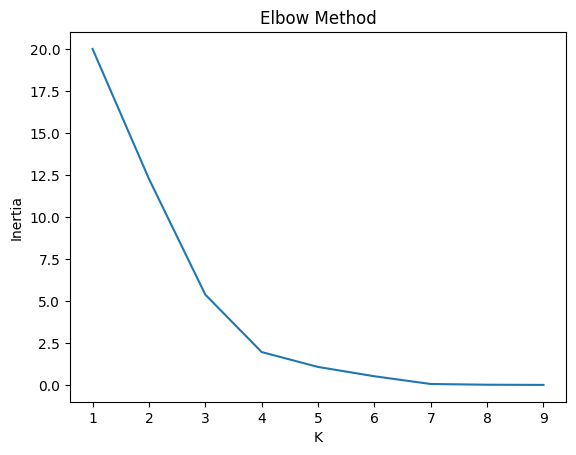

In [34]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 10), inertia)
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3810
K = 3, Silhouette Score = 0.4253
K = 4, Silhouette Score = 0.4966
K = 5, Silhouette Score = 0.5529
K = 6, Silhouette Score = 0.5361
K = 7, Silhouette Score = 0.4705
K = 8, Silhouette Score = 0.3289
K = 9, Silhouette Score = 0.1627


In [36]:
kmeans = KMeans(n_clusters=5, random_state=42)
features["Cluster"] = kmeans.fit_predict(X_scaled)

In [37]:
cluster_summary = features.groupby("Cluster")[['Avg_Return','Avg_Intraday_Vol']].mean()
print(cluster_summary)

         Avg_Return  Avg_Intraday_Vol
Cluster                              
0          0.000422          0.014661
1         -0.000685          0.018554
2          0.000621          0.022011
3         -0.001746          0.016066
4          0.000194          0.016662


In [38]:
def label_cluster(row):
    if row['Avg_Return'] > 0 and row['Avg_Intraday_Vol'] > 0.03:
        return "High Risk - High Return (Aggressive)"
    
    elif row['Avg_Return'] > 0 and row['Avg_Intraday_Vol'] <= 0.03:
        return "Low Risk - Steady Return (Stable)"
    
    elif row['Avg_Return'] <= 0 and row['Avg_Intraday_Vol'] > 0.03:
        return "High Risk - Poor Return (Speculative Loss)"
    
    else:
        return "Low Risk - Low Return (Defensive)"

cluster_summary['Profile'] = cluster_summary.apply(label_cluster, axis=1)

print(cluster_summary)

         Avg_Return  Avg_Intraday_Vol                            Profile
Cluster                                                                 
0          0.000422          0.014661  Low Risk - Steady Return (Stable)
1         -0.000685          0.018554  Low Risk - Low Return (Defensive)
2          0.000621          0.022011  Low Risk - Steady Return (Stable)
3         -0.001746          0.016066  Low Risk - Low Return (Defensive)
4          0.000194          0.016662  Low Risk - Steady Return (Stable)


In [39]:
features = features.merge(cluster_summary["Profile"], on="Cluster", how="left")

In [40]:
features

,Stock,Avg_Return,Avg_Intraday_Vol,Cluster,Profile
0,BAJFINANCE.NS,0.000621,0.022011,2,Low Risk - Steady Return (Stable)
1,HDFCBANK.NS,0.000353,0.014934,0,Low Risk - Steady Return (Stable)
2,HINDUNILVR.NS,-0.000730,0.017940,1,Low Risk - Low Return (Defensive)
3,ICICIBANK.NS,0.000490,0.014388,0,Low Risk - Steady Return (Stable)
4,INFY.NS,-0.000466,0.019774,1,Low Risk - Low Return (Defensive)
5,ITC.NS,-0.001723,0.015003,3,Low Risk - Low Return (Defensive)
6,LT.NS,-0.000860,0.017949,1,Low Risk - Low Return (Defensive)
7,RELIANCE.NS,0.000131,0.016647,4,Low Risk - Steady Return (Stable)
8,SBIN.NS,0.000257,0.016676,4,Low Risk - Steady Return (Stable)
9,TCS.NS,-0.001768,0.017129,3,Low Risk - Low Return (Defensive)


In [42]:
df = pd.merge(df,features, on='Stock', how='left')

In [43]:
df

,Date,Open,High,Low,Close,Volume,Stock,Return,Volume_Change,Daily_Range,Intraday_Volatility,Avg_Return,Avg_Intraday_Vol,Cluster,Profile
0,2025-03-27 03:45:00,886.099976,905.539978,882.224976,900.385010,20920440,BAJFINANCE.NS,0.016121,NaN,23.315002,0.026312,0.000621,0.022011,2,Low Risk - Steady Return (Stable)
1,2025-03-28 03:45:00,899.760010,902.890015,886.099976,894.559998,9770990,BAJFINANCE.NS,-0.005779,-0.532945,16.790039,0.018661,0.000621,0.022011,2,Low Risk - Steady Return (Stable)
2,2025-04-01 03:45:00,878.330017,892.500000,867.099976,869.820007,11834240,BAJFINANCE.NS,-0.009689,0.211161,25.400024,0.028919,0.000621,0.022011,2,Low Risk - Steady Return (Stable)
3,2025-04-02 03:45:00,873.000000,875.984985,861.200012,866.924988,6464950,BAJFINANCE.NS,-0.006959,-0.453708,14.784973,0.016936,0.000621,0.022011,2,Low Risk - Steady Return (Stable)
4,2025-04-03 03:45:00,865.000000,876.500000,846.020020,859.460022,13966330,BAJFINANCE.NS,-0.006405,1.160315,30.479980,0.035237,0.000621,0.022011,2,Low Risk - Steady Return (Stable)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2475,2026-03-20 03:45:00,2386.000000,2407.800049,2364.199951,2390.600098,4206320,TCS.NS,0.001928,0.525654,43.600098,0.018273,-0.001768,0.017129,3,Low Risk - Low Return (Defensive)
2476,2026-03-23 03:45:00,2365.000000,2406.800049,2348.000000,2383.800049,3860515,TCS.NS,0.007949,-0.082211,58.800049,0.024863,-0.001768,0.017129,3,Low Risk - Low Return (Defensive)
2477,2026-03-24 03:45:00,2404.100098,2435.399902,2379.100098,2398.800049,3420182,TCS.NS,-0.002205,-0.114061,56.299805,0.023418,-0.001768,0.017129,3,Low Risk - Low Return (Defensive)
2478,2026-03-25 03:45:00,2400.899902,2421.600098,2369.800049,2377.399902,5843778,TCS.NS,-0.009788,0.708616,51.800049,0.021575,-0.001768,0.017129,3,Low Risk - Low Return (Defensive)


In [44]:
df.to_csv('final_data.csv')